In [ ]:
# | default_exp dmd_scaling_dataset

# Scaling the Yin-Yang MLP

> We scale a neural network by freezing it and adding new trainable layers.

#### Imports and Setup

In [ ]:
import os
from ast import literal_eval
from copy import deepcopy

import graphviz
import matrepr
import torch
import torchinfo
from safetensors.torch import load_model, save_model
from torch import nn
from torch.nn import CrossEntropyLoss, L1Loss, MSELoss, HuberLoss
from torch.optim import SGD, Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchviz import make_dot

from learningdynamics.datasets import YinYangBinaryDataset
from learningdynamics.models import MLP, init_weights
from learningdynamics.utils import (
    compute_model_accuracy,
    getActivation,
    safetensors_metadata_parser,
)
import numpy as np
from learningdynamics.visualization import plot_decision_boundary_movie
import matplotlib.pyplot as plt

In [ ]:
# | hide
matrepr.params.title = True
matrepr.params.indices = False
matrepr.params.precision = 4
matrepr.cell_align = "left"
graphviz.set_jupyter_format("png")

%matplotlib inline

#### Load model

In [ ]:
file_path = "../saved_weights/yinyang_model.safetensors"

# Parse metadata
metadata = safetensors_metadata_parser(file_path=file_path)
PROBLEM = metadata["dataset"]

# Load model
model = MLP(
    config=literal_eval(metadata["config"]), nonlinearity=metadata["nonlinearity"]
)
_ = load_model(model, file_path, device="cuda:0")

#### Setup the dataset

In [ ]:
NUM_SAMPLES = 2_000

dataset = YinYangBinaryDataset(num_samples=NUM_SAMPLES, negative_label=False, seed=123)

#### Visualize decision boundary

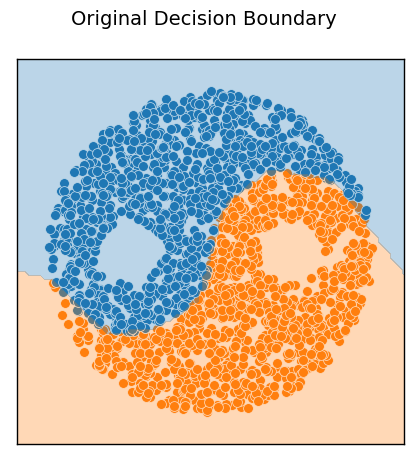

In [ ]:
# Example of integrating multiple subplots into a larger figure
fig, axs = plt.subplots(1,1, figsize=(5,5), sharex=True, sharey=True)

if type(axs) is not np.ndarray:
    axs = np.array(axs)

# Assume you have a model, state_dicts, X, and y already defined
for i, ax in enumerate(axs.flatten()):
    ani = plot_decision_boundary_movie(
            model,
            [model.state_dict()],
            dataset.features,
            dataset.labels.squeeze(),
            labels=[0, 1],
            ax=ax,
    )
    ax.get_legend().remove()

plt.suptitle("Original Decision Boundary", fontsize=14)
# fig.supxlabel('common x label', fontsize=12)
# fig.supylabel('common y label', fontsize=12)
plt.xticks([])
plt.yticks([])
plt.show()


In [ ]:
print(f"Testing Accuracy: {compute_model_accuracy(model, dataset)}")

Testing Accuracy: 0.984499990940094


In [ ]:
torchinfo.summary(model, row_settings=["var_names", "ascii_only"])

Layer (type (var_name))                  Param #
MLP (MLP)                                --
+ Sequential (features)                  --
|    + Linear (0)                        24
|    + ReLU (1)                          --
|    + Linear (2)                        54
|    + ReLU (3)                          --
|    + Linear (4)                        28
|    + ReLU (5)                          --
|    + Linear (6)                        15
|    + ReLU (7)                          --
|    + Linear (8)                        8
Total params: 129
Trainable params: 129
Non-trainable params: 0

#### Define model scaling

In [ ]:
def freeze_and_scale_model(
    model,
    start,
    layers_to_add=1,
    device="cuda:0",
):
    # Set up scaled model
    model.to(device)
    scaled_model = deepcopy(model)

    # Build new layers
    scaled_container = torch.nn.Sequential()
    for idx, module in enumerate(scaled_model.features):
        if hasattr(module, "weight"):
            module.weight.requires_grad_(False)
        if hasattr(module, "bias"):
            module.bias.requires_grad_(False)
        scaled_container.append(module)
        if idx == start:
            prev_out = model.features[idx - 1].out_features
            for _ in range(layers_to_add):
                linear_layer = nn.Linear(prev_out, prev_out)
                linear_layer.apply(init_weights)
                scaled_container.append(linear_layer)
                scaled_container.append(nn.ReLU())
    scaled_model.features = scaled_container
    scaled_model.to(device=device)

    scaled_model.to(device="cpu")
    return scaled_model

#### Control panel

In [ ]:
DEVICE = "cuda:1"
PRINT_FREQ = 500

NUM_LAYERS_ADDED = 10
LAYER_START = 3
DIMENSIONALITY = model.features[LAYER_START + 1].in_features
LAYER_END = LAYER_START + 2

DELTA = 1
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 512
NUM_EPOCHS = 3_000
LEARNING_RATE = 2e-3
BETAS = (0.8, 0.8)

#### Scale model

In [ ]:
dataloader = DataLoader(dataset=dataset, shuffle=True, batch_size=BATCH_SIZE)

scaled_model = freeze_and_scale_model(
    model,
    start=LAYER_START,
    layers_to_add=NUM_LAYERS_ADDED,
    device=DEVICE
)

torchinfo.summary(scaled_model, row_settings=["var_names", "ascii_only"])

Layer (type (var_name))                  Param #
MLP (MLP)                                --
+ Sequential (features)                  --
|    + Linear (0)                        (24)
|    + ReLU (1)                          --
|    + Linear (2)                        (54)
|    + ReLU (3)                          --
|    + Linear (4)                        42
|    + ReLU (5)                          --
|    + Linear (6)                        42
|    + ReLU (7)                          --
|    + Linear (8)                        42
|    + ReLU (9)                          --
|    + Linear (10)                       42
|    + ReLU (11)                         --
|    + Linear (12)                       42
|    + ReLU (13)                         --
|    + Linear (14)                       42
|    + ReLU (15)                         --
|    + Linear (16)                       42
|    + ReLU (17)                         --
|    + Linear (18)                       42
|    + ReLU (19)       

In [ ]:
print(f"Testing Accuracy: {compute_model_accuracy(scaled_model.to('cpu'), dataset)}")

Testing Accuracy: 0.5005000233650208


#### Train scaled model

In [ ]:
activation_dict = {}
hooks = []

In [ ]:
# Setup training
huber_criterion = HuberLoss(delta=DELTA)
mse_criterion = MSELoss()
optimizer = AdamW(scaled_model.parameters(), lr=LEARNING_RATE, betas=BETAS, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=300, threshold=0.0001, verbose=True
)

In [ ]:
scaled_model.to(DEVICE)
scaled_model.train()

# Attach hook to original
hooks.append(
    model.features[LAYER_END].register_forward_hook(
        getActivation(f"layer_{LAYER_END}", activation_dict)
    )
)

# Attach hook to scaled
new_end = LAYER_END + NUM_LAYERS_ADDED * 2
hooks.append(
    scaled_model.features[new_end].register_forward_hook(
        getActivation(f"scaled_layer_{new_end}", activation_dict, detach=False)
    )
)

# Run training
loss_vector = []
for epoch in range(NUM_EPOCHS):
    running_loss = 0.0  # Track loss within the epoch

    # Iterate through dataloader
    for input, label in dataloader:
        # Feed input in to get activations
        input, label = input.to(DEVICE), torch.flatten(label.to(DEVICE))
        output = scaled_model(input)

        with torch.no_grad():
            _ = model(input)

        # Zero out optimizer
        optimizer.zero_grad()

        # Grab activations
        output_activation = activation_dict[f"scaled_layer_{new_end}"].to(DEVICE)
        target_activation = activation_dict[f"layer_{LAYER_END}"].to(DEVICE)

        huber_loss = huber_criterion(output_activation, target_activation)
        mse_loss = mse_criterion(output_activation, target_activation)

        loss = huber_loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item()  # Accumulate loss

    epoch_loss = running_loss / len(dataloader)  # Average loss over all batches
    loss_vector.append(epoch_loss)  # Store loss for later analysis

    # Step the scheduler
    scheduler.step(epoch_loss)

    epoch_loss = running_loss / len(dataloader)  # Average loss over all batches
    loss_vector.append(epoch_loss)  # Store loss for later analysis

    if (epoch + 1) % PRINT_FREQ == 0:
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}")

# Remove hook
for hook in hooks:
    hook.remove()

Epoch 500/3000, Loss: 0.0014
Epoch 1000/3000, Loss: 0.0001
Epoch 01452: reducing learning rate of group 0 to 1.0000e-03.
Epoch 1500/3000, Loss: 0.0001
Epoch 2000/3000, Loss: 0.0001
Epoch 02446: reducing learning rate of group 0 to 5.0000e-04.
Epoch 2500/3000, Loss: 0.0000
Epoch 3000/3000, Loss: 0.0000


#### Visualize scaled model boundary

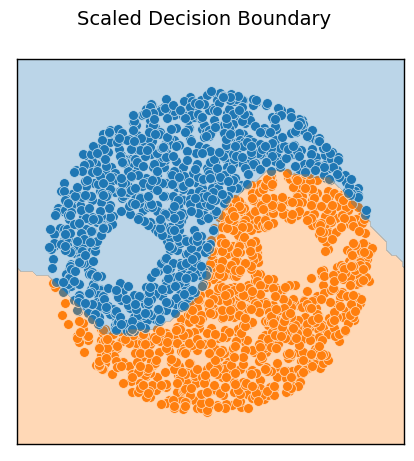

In [ ]:
# Example of integrating multiple subplots into a larger figure
fig, axs = plt.subplots(1,1, figsize=(5,5), sharex=True, sharey=True)

if type(axs) is not np.ndarray:
    axs = np.array(axs)

# Assume you have a model, state_dicts, X, and y already defined
for i, ax in enumerate(axs.flatten()):
    ani = plot_decision_boundary_movie(
            scaled_model,
            [scaled_model.state_dict()],
            dataset.features,
            dataset.labels.squeeze(),
            labels=[0, 1],
            ax=ax,
    )
    ax.get_legend().remove()

plt.suptitle("Scaled Decision Boundary", fontsize=14)
# fig.supxlabel('common x label', fontsize=12)
# fig.supylabel('common y label', fontsize=12)
plt.xticks([])
plt.yticks([])
plt.show()


In [ ]:
print(f"Testing Accuracy: {compute_model_accuracy(scaled_model.to('cpu'), dataset)}")

Testing Accuracy: 0.9869999885559082


#### Update config

In [ ]:
config = literal_eval(metadata["config"])
insert = [model.features[LAYER_START - 1].out_features] * NUM_LAYERS_ADDED
config[LAYER_START // 2 : LAYER_START // 2] = insert

In [ ]:
metadata_dict = {
    "config": str(config),
    "dataset": metadata["dataset"],
    "nonlinearity": metadata["nonlinearity"],
    "added_layers": str(NUM_LAYERS_ADDED),
    "layer_start": str(LAYER_START),
    "layer_in_out": str(DIMENSIONALITY),
}

save_model(
    scaled_model,
    f"../saved_weights/yinyang_start{LAYER_START}_scaled_model.safetensors",
    metadata=metadata_dict,
)